# Layer 1 EDA — Cascade Phish Guard

This notebook explores the URL features before any model training starts, comparing phishing links against legitimate ones to check they actually look different from each other.

## Where things stand right now

This is an early checkpoint, not the finished dataset. So far, the project has:
- Collected phishing and legitimate web addresses from multiple public sources, and cross-checked them against each other so only addresses confirmed by more than one source count as "phishing."
- Built a set of measurable properties for each web address (length, structure, how random it looks, how old the domain is, how close it looks to a well known brand name, and similar signals).
- Run this exploratory check below on a small trial batch, just to confirm the whole process works correctly end to end before scaling it up.

The next step after this is training the actual classification models. The full size version of this same analysis will be re run later once data collection wraps up, and the numbers below will grow accordingly  right now the goal is just to confirm the approach is sound, not to draw final conclusions.

**A quick safety note:** a few real, recently-active phishing web addresses appear as example data further down this notebook, for illustration only. Please don't open any of them directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

> **Reminder:** the `url` column in the table below includes real, recently-active phishing web addresses. Please view them as text only  don't click or open any of them directly.

In [2]:
train = pd.read_csv("../data/processed/layer1_train_features.csv")
val = pd.read_csv("../data/processed/layer1_validation_features.csv")
df = pd.concat([train, val], ignore_index=True)

FEATURE_COLUMNS = [
    "url_length", "subdomain_count", "has_https", "special_char_count",
    "keyword_score", "character_entropy", "tld_risk_score", "has_ip_host",
    "has_at_symbol", "path_depth", "query_param_count", "digit_ratio",
    "is_punycode_or_homograph", "tranco_rank_bucket", "brand_distance_score",
    "brand_keyword_in_host", "domain_age_days",
]

print(f"Combined EDA set: {len(df)} rows ({len(train)} train + {len(val)} validation)")
df.head()

Combined EDA set: 20269 rows (16705 train + 3564 validation)


,url,source,collected_date,confirmation_method,is_reachable,http_status,reachability_error,label,rank,url_length,subdomain_count,has_https,special_char_count,keyword_score,character_entropy,tld_risk_score,has_ip_host,has_at_symbol,path_depth,query_param_count,digit_ratio,is_punycode_or_homograph,tranco_rank_bucket,brand_distance_score,brand_keyword_in_host,domain_age_days
0,https://sin1.contabostorage.com/d96fc17aeb3741...,openphish,2026-08-08,feed_domain,True,200.0,NaN,1,NaN,91,2,1,0,1,4.708007,0.0,0,0,2,0,0.219780,0,0,9,0,NaN
1,https://sin1.contabostorage.com/917d51abc29e43...,openphish,2026-08-14,feed_domain,True,403.0,NaN,1,NaN,113,2,1,0,0,4.630144,0.0,0,0,2,0,0.389381,0,0,9,0,NaN
2,https://sin1.contabostorage.com/ab70d71dd53c4e...,openphish,2026-07-29,feed_domain,True,200.0,NaN,1,NaN,155,2,1,2,0,4.913858,0.0,0,0,2,0,0.232258,0,0,9,0,NaN
3,https://sin1.contabostorage.com/7713e3a06a2c43...,openphish,2026-08-16,feed_domain,True,401.0,NaN,1,NaN,158,2,1,4,0,4.600462,0.0,0,0,2,1,0.474684,0,0,9,0,NaN
4,https://sin1.contabostorage.com/d96fc17aeb3741...,openphish,2026-07-30,feed_domain,True,200.0,NaN,1,NaN,163,2,1,2,1,4.741756,0.0,0,0,2,0,0.141104,0,0,9,0,NaN


## Class balance

label
legitimate    10523
phishing       9746
Name: count, dtype: int64

phishing share: 48.1%


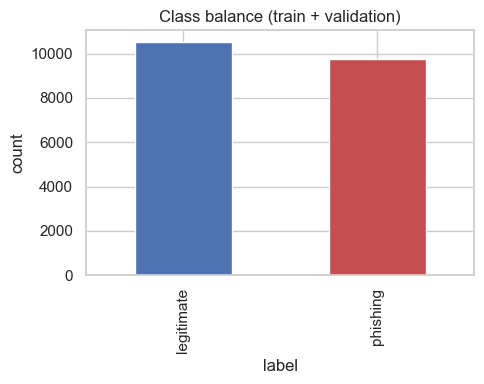

In [3]:
counts = df["label"].value_counts().rename({0: "legitimate", 1: "phishing"})
print(counts)
print(f"\nphishing share: {counts.get('phishing', 0) / len(df):.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Class balance (train + validation)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## Missing values

`domain_age_days` (how long the domain has existed) is expected to have the most gaps  that information isn't always publicly available, especially for newer or less established domains, which phishing sites often are.

In [4]:
missing = df[FEATURE_COLUMNS].isna().mean().sort_values(ascending=False)
print(missing)

missing_by_class = df.groupby("label")["domain_age_days"].apply(lambda s: s.isna().mean())
missing_by_class.index = missing_by_class.index.map({0: "legitimate", 1: "phishing"})
print("\ndomain_age_days null rate by class:")
print(missing_by_class)

domain_age_days             0.560166
path_depth                  0.000000
brand_keyword_in_host       0.000000
brand_distance_score        0.000000
tranco_rank_bucket          0.000000
is_punycode_or_homograph    0.000000
digit_ratio                 0.000000
query_param_count           0.000000
url_length                  0.000000
subdomain_count             0.000000
has_ip_host                 0.000000
tld_risk_score              0.000000
character_entropy           0.000000
keyword_score               0.000000
special_char_count          0.000000
has_https                   0.000000
has_at_symbol               0.000000
dtype: float64

domain_age_days null rate by class:
label
legitimate    0.168583
phishing      0.982967
Name: domain_age_days, dtype: float64


## Per-feature distributions: phishing vs. legitimate

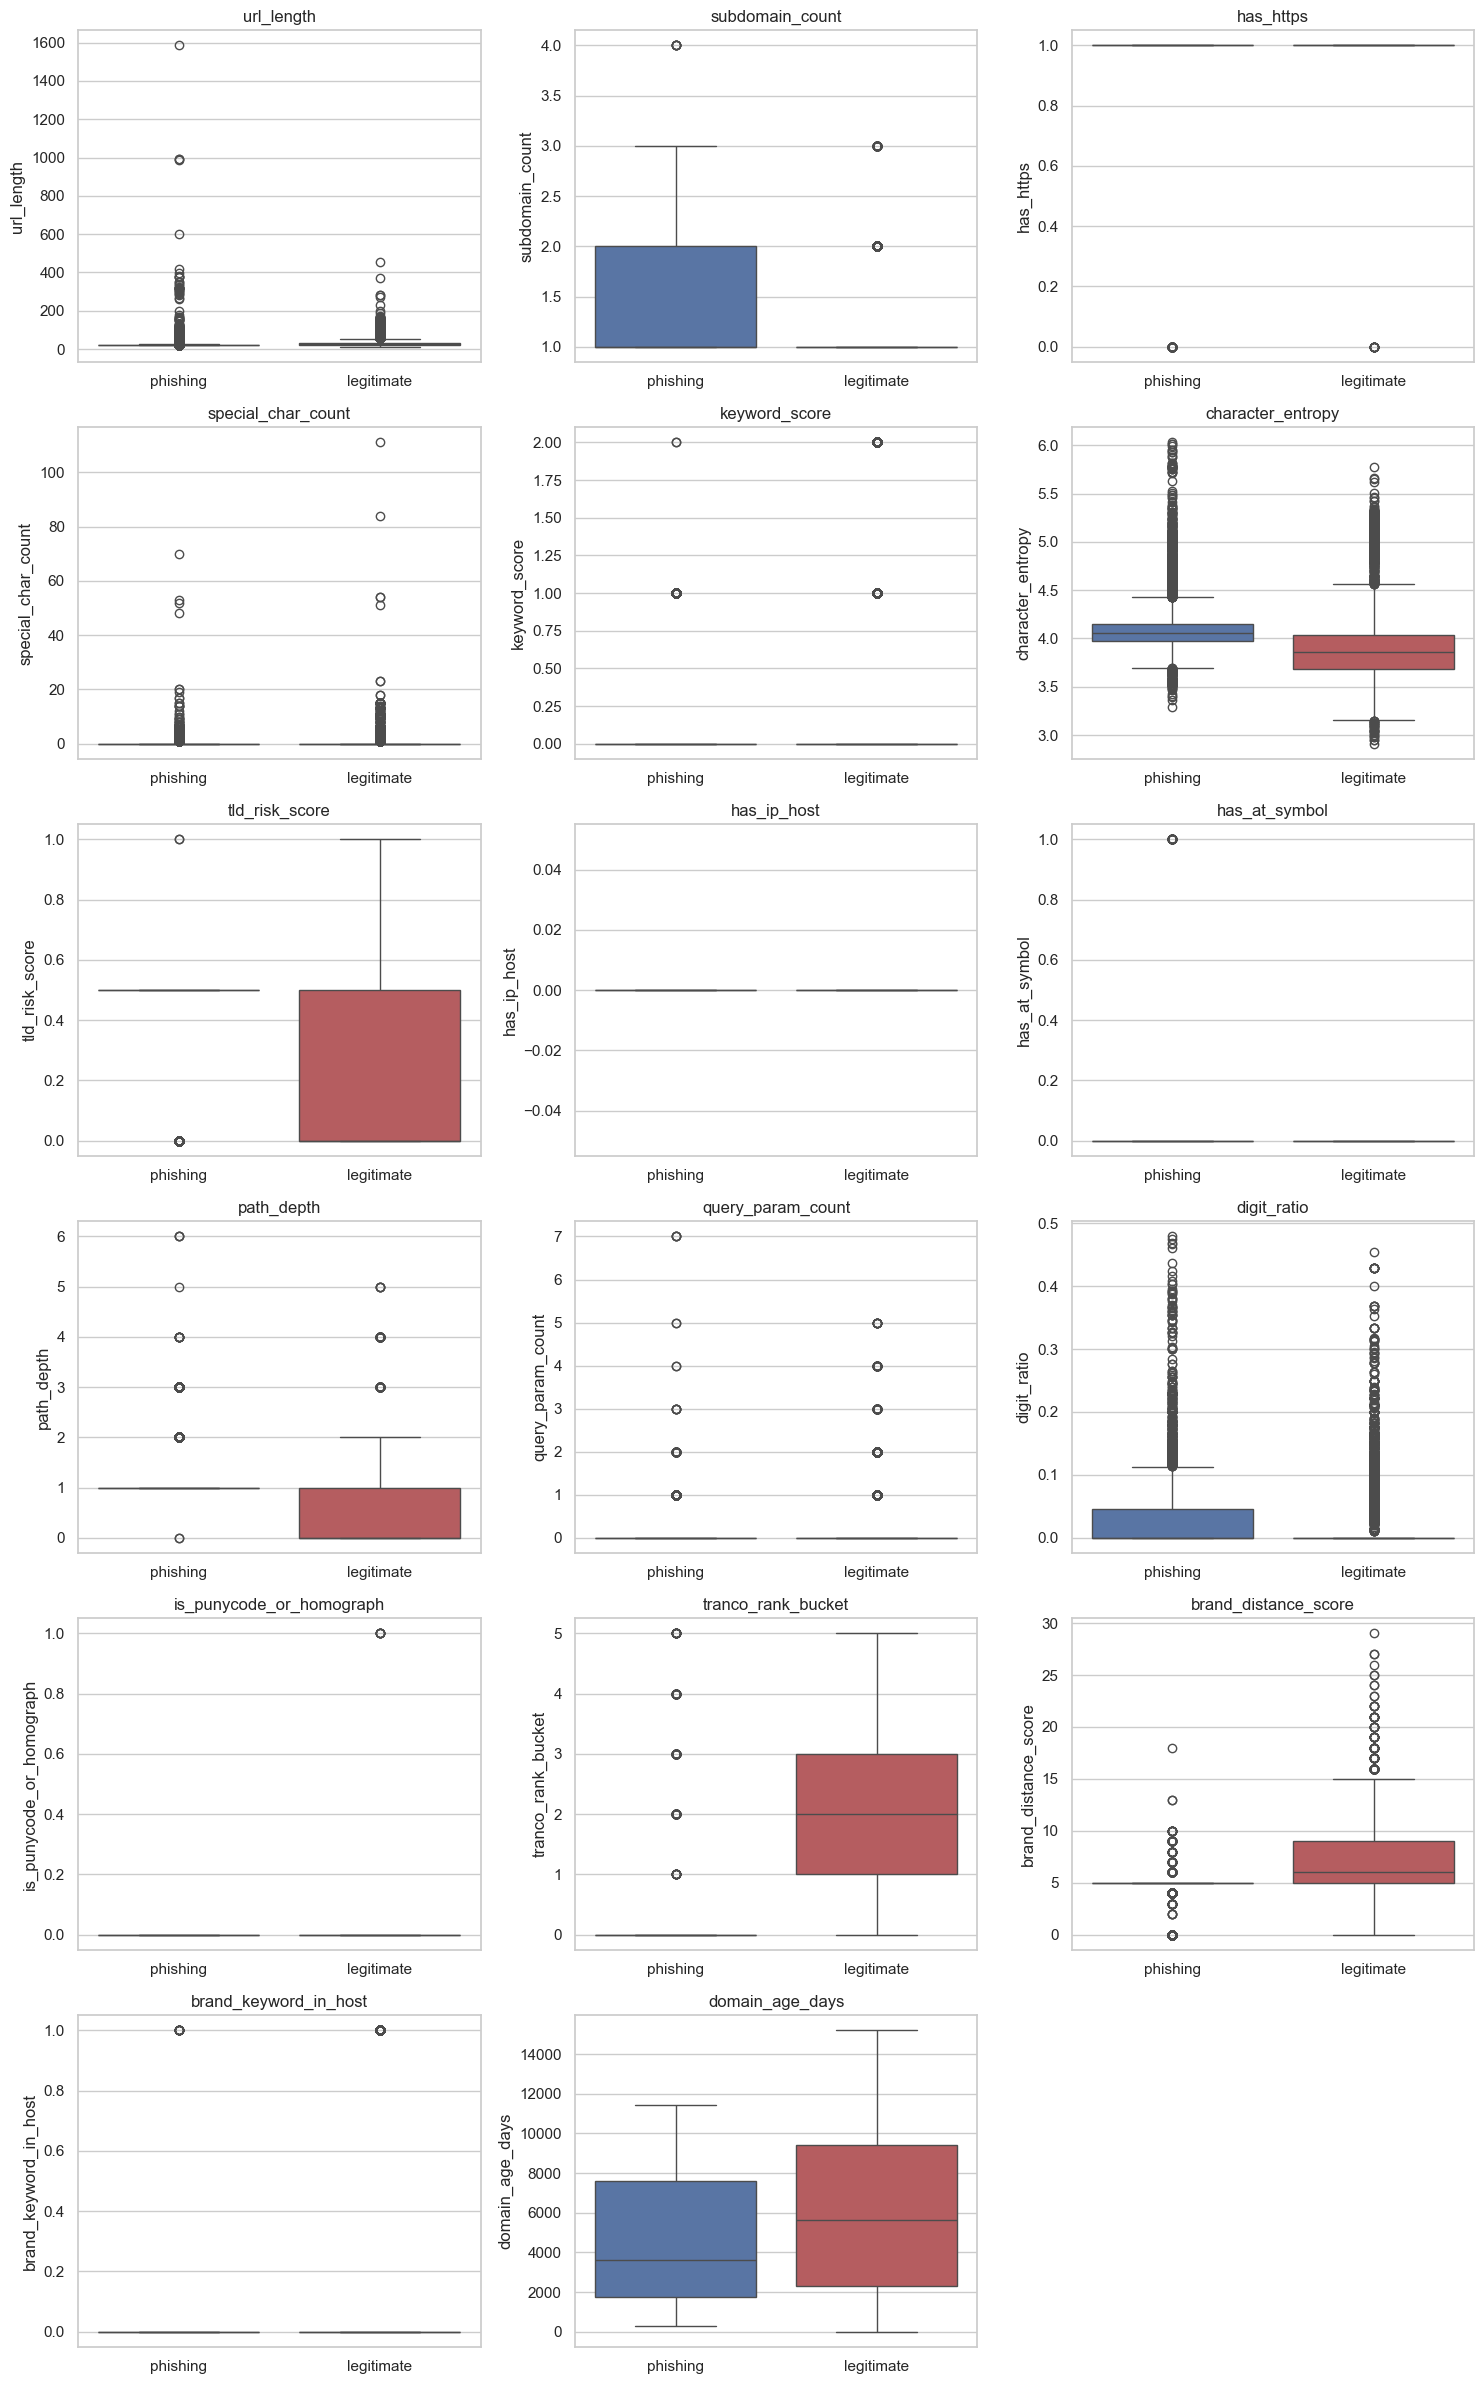

In [5]:
n_cols = 3
n_rows = int(np.ceil(len(FEATURE_COLUMNS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]
    plot_df = df[[col, "label"]].dropna()
    plot_df["class"] = plot_df["label"].map({0: "legitimate", 1: "phishing"})
    sns.boxplot(data=plot_df, x="class", y=col, hue="class", palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

for j in range(len(FEATURE_COLUMNS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Statistical significance: Mann Whitney U per feature

Non-parametric test (doesn't assume normally-distributed features, appropriate given the small current sample and generally skewed distributions like `url_length` or `character_entropy`). A low p-value (< 0.05) means phishing and legitimate URLs differ significantly on that feature.

In [6]:
results = []
for col in FEATURE_COLUMNS:
    phishing_vals = df.loc[df["label"] == 1, col].dropna()
    legit_vals = df.loc[df["label"] == 0, col].dropna()
    if len(phishing_vals) < 2 or len(legit_vals) < 2:
        results.append({"feature": col, "u_stat": None, "p_value": None, "significant": None})
        continue
    u_stat, p_value = mannwhitneyu(phishing_vals, legit_vals, alternative="two-sided")
    results.append({
        "feature": col,
        "u_stat": u_stat,
        "p_value": p_value,
        "significant": p_value < 0.05,
    })

results_df = pd.DataFrame(results).sort_values("p_value")
results_df

,feature,u_stat,p_value,significant
1,subdomain_count,67808594.0,0.000000e+00,True
5,character_entropy,74652117.5,0.000000e+00,True
6,tld_risk_score,74225104.0,0.000000e+00,True
14,brand_distance_score,25647288.5,0.000000e+00,True
9,path_depth,74174687.0,0.000000e+00,True
13,tranco_rank_bucket,1259053.0,0.000000e+00,True
4,keyword_score,43449205.0,1.710870e-303,True
11,digit_ratio,63158122.5,3.304961e-257,True
3,special_char_count,42506094.0,3.396895e-239,True
10,query_param_count,46008796.5,2.145979e-156,True


## Correlation between features

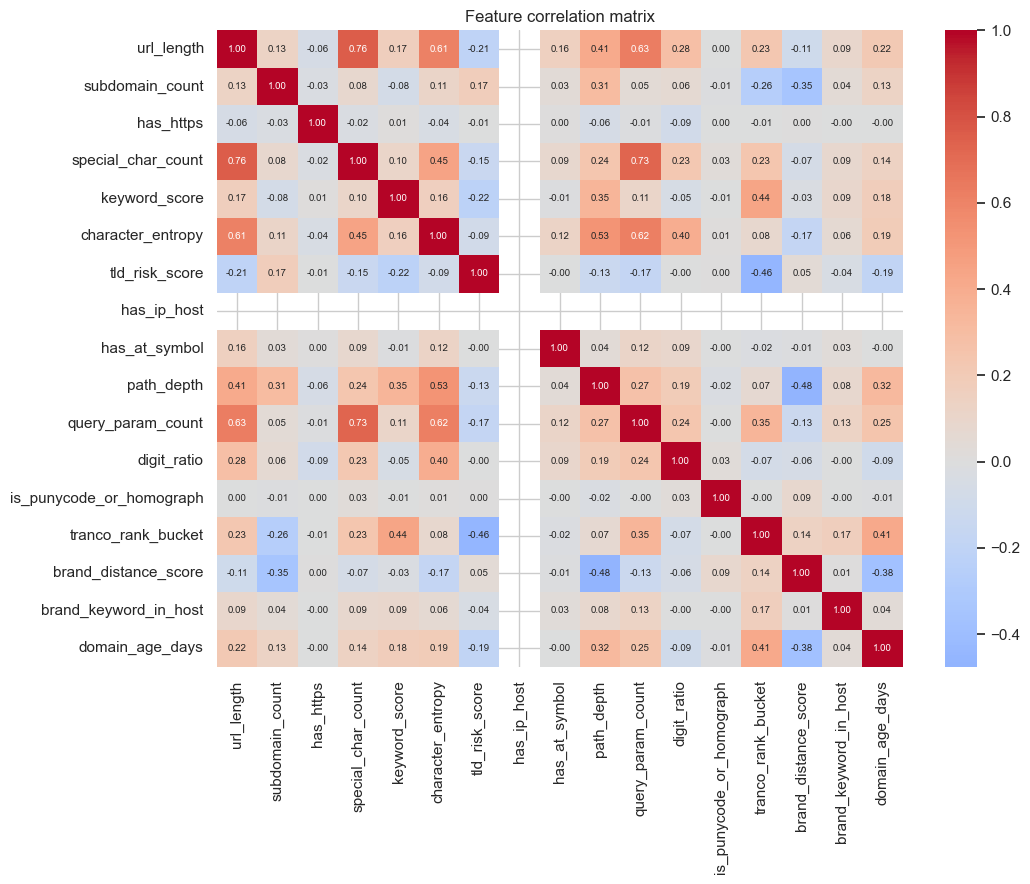

In [7]:
corr = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## Summary

- Class balance, missing-value rates, per-feature distributions, statistical separation, and feature correlation are all shown above.
- **This run is on placeholder-scale data** (see the scope note at the top)  treat specific p-values and effect sizes as provisional; the same notebook will be re-run unchanged once the full dataset is finalized, at which point these findings become the ones reported in the paper.
- Features with a significant Mann-Whitney result at this scale are worth watching as the dataset grows, but a feature *not* reaching significance here isn't conclusive yet, given the small current phishing sample size.